# Multimodal Product Recommendation using Image and Text Embeddings

This notebook walks through the whole project:

1. **Dataset**: a fashion product catalog where each product has an image, a title and metadata
2. **Encoders**: text-only, image-only and vision-language models
3. **Fusion**: combining image and text similarity into one recommendation score
4. **Evaluation**: comparing 11 recommendation systems on item-to-item and text-search tasks
5. **Analysis**: fusion-weight sweep, embedding-space visualisation, zero-shot text-to-image search

> Run `python -m src.data` and `python -m src.embeddings` first. This notebook reads the cached embeddings, so it runs in a few minutes on a CPU.

In [1]:
import os, warnings
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["HF_HUB_VERBOSITY"] = "error"
os.environ["TQDM_DISABLE"] = "1"  # hide progress bars
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from src.config import IMAGE_DIR, RESULTS_DIR
from src.data import load_catalog
from src.recommender import SYSTEMS, SYSTEMS_BY_NAME, Recommender
from src import embeddings
from src.evaluate import eval_item2item
%matplotlib inline

pd.set_option("display.precision", 3)
plt.rcParams["figure.dpi"] = 100

## 1. Dataset

`ashraq/fashion-product-images-small` from Hugging Face: product photos with titles and category labels. We use a random sample of 3,000 products.

In [2]:
df = load_catalog()
print(f"{len(df):,} products | {df['articleType'].nunique()} article types | "
      f"{df['baseColour'].nunique()} colours | {df['masterCategory'].nunique()} master categories")
df[["productDisplayName", "masterCategory", "subCategory", "articleType", "baseColour", "gender"]].head()

3,000 products | 66 article types | 42 colours | 4 master categories


,productDisplayName,masterCategory,subCategory,articleType,baseColour,gender
0,Fabindia Women Anusuya Silver Earrings,Accessories,Jewellery,Earrings,Silver,Women
1,Doodle Kids Girl Printed Off White Dress,Apparel,Dress,Dresses,Off White,Women
2,Fabindia Blue Necklace,Accessories,Jewellery,Necklace and Chains,Blue,Women
3,Rocia Women Brown Heels,Footwear,Shoes,Heels,Brown,Women
4,United Colors of Benetton Men Check Multi Shirt,Apparel,Topwear,Shirts,Multi,Men


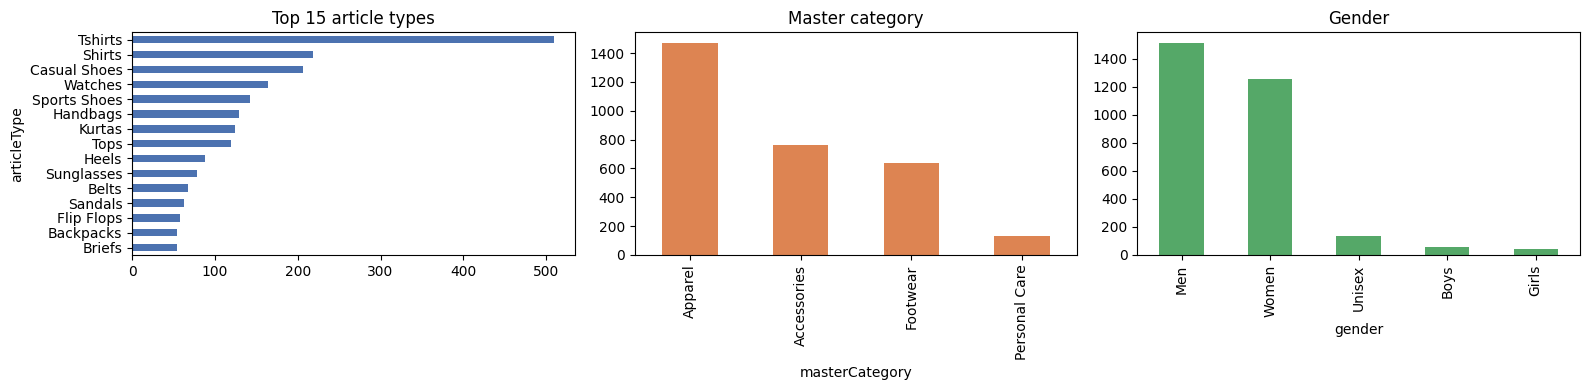

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df["articleType"].value_counts().head(15).plot.barh(ax=axes[0], color="#4C72B0").invert_yaxis()
axes[0].set_title("Top 15 article types")
df["masterCategory"].value_counts().plot.bar(ax=axes[1], color="#DD8452")
axes[1].set_title("Master category")
df["gender"].value_counts().plot.bar(ax=axes[2], color="#55A868")
axes[2].set_title("Gender")
plt.tight_layout()

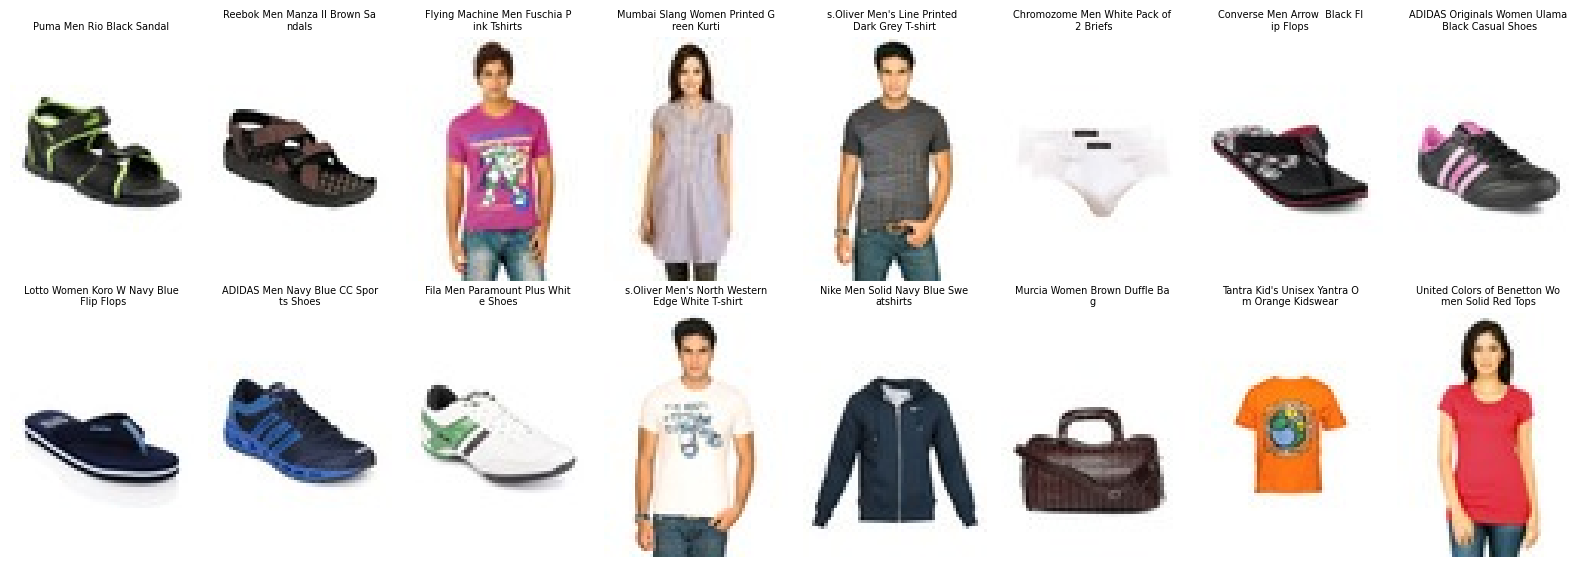

In [4]:
def show_products(indices, titles=None, ncols=8, size=2.0, header=None):
    n = len(indices)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * size, nrows * size * 1.45))
    for ax in np.atleast_1d(axes).ravel():
        ax.axis("off")
    for k, (ax, i) in enumerate(zip(np.atleast_1d(axes).ravel(), indices)):
        ax.imshow(Image.open(IMAGE_DIR / df.iloc[i]["image_path"]))
        t = titles[k] if titles else df.iloc[i]["productDisplayName"]
        ax.set_title(t[:28] + ("\n" + t[28:56] if len(t) > 28 else ""), fontsize=7)
    if header:
        fig.suptitle(header, fontsize=12, fontweight="bold")
        plt.tight_layout(rect=(0, 0, 1, 0.88))
    else:
        plt.tight_layout()

show_products(np.random.default_rng(1).choice(len(df), 16, replace=False))

## 2. Encoders

| Group | Model | Output dim | Idea |
|---|---|---|---|
| text | TF-IDF | vocab-sized | lexical word/bigram overlap (baseline) |
| text | MiniLM (`all-MiniLM-L6-v2`) | 384 | sentence-transformer semantic embedding |
| image | ResNet-50 (ImageNet) | 2048 | supervised CNN features |
| image | DINOv2-small | 384 | self-supervised ViT features |
| image + text | CLIP ViT-B/32 | 512 | contrastive image-text model with a shared embedding space |
| image + text | SigLIP base | 768 | CLIP-style model trained with a sigmoid loss |

Only the **product title** is embedded as text. Category and colour fields are the evaluation labels, so feeding them to the model would leak the answers.

In [5]:
rows = []
for m in ["TF-IDF", "MiniLM", "ResNet50", "DINOv2", "CLIP", "SigLIP"]:
    for mod in ["text", "image"]:
        X = embeddings.load(m, mod)
        if X is not None:
            rows.append({"model": m, "modality": mod, "shape": X.shape,
                         "mean |norm|": np.linalg.norm(X, axis=1).mean()})
pd.DataFrame(rows)

,model,modality,shape,mean |norm|
0,TF-IDF,text,"(3000, 7372)",1.0
1,MiniLM,text,"(3000, 384)",1.0
2,ResNet50,image,"(3000, 2048)",1.0
3,DINOv2,image,"(3000, 384)",1.0
4,CLIP,text,"(3000, 512)",1.0
5,CLIP,image,"(3000, 512)",1.0
6,SigLIP,text,"(3000, 768)",1.0
7,SigLIP,image,"(3000, 768)",1.0


## 3. Fusion

All embeddings are L2-normalised, so the dot product equals cosine similarity. A system uses an image model and/or a text model and scores each catalog item as

$$\text{score}(q, i) = w \cdot \cos(q_{img}, I_i) + (1 - w) \cdot \cos(q_{txt}, T_i)$$

where $w$ is the **image weight**. In CLIP and SigLIP, text and images share one space, so a *text* query can be matched directly against product *images* (zero-shot).

In [6]:
import inspect
from src.recommender import Recommender
print(inspect.getsource(Recommender.query_scores))

    def query_scores(self, q_img: np.ndarray | None = None, q_txt: np.ndarray | None = None,
                     q_img_textenc: np.ndarray | None = None, q_txt_imgenc: np.ndarray | None = None):
        """
        q_img:          query image embedded with the image model
        q_txt:          query text embedded with the text model
        q_img_textenc:  query image embedded with the *text* model (only for shared-space models)
        q_txt_imgenc:   query text embedded with the *image* model (only for shared-space models)
        """
        parts, weights = [], []
        if self.I is not None:
            v = [x for x in (q_img, q_txt_imgenc) if x is not None]
            if v:
                parts.append(self.I @ _norm(np.sum(v, axis=0)))
                weights.append(self.w)
        if self.T is not None:
            v = [x for x in (q_txt, q_img_textenc) if x is not None]
            if v:
                parts.append(self.T @ _norm(np.sum(v, axis=0)))
                weig

## 4. Qualitative example: the same query product, three systems

✓ = same article type as the query, ✗ = different.

Query: Skechers Men Masterson Silver Sports Shoes | Sports Shoes | Silver


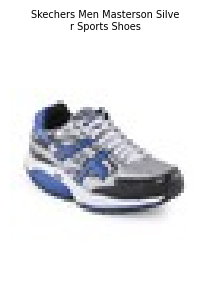

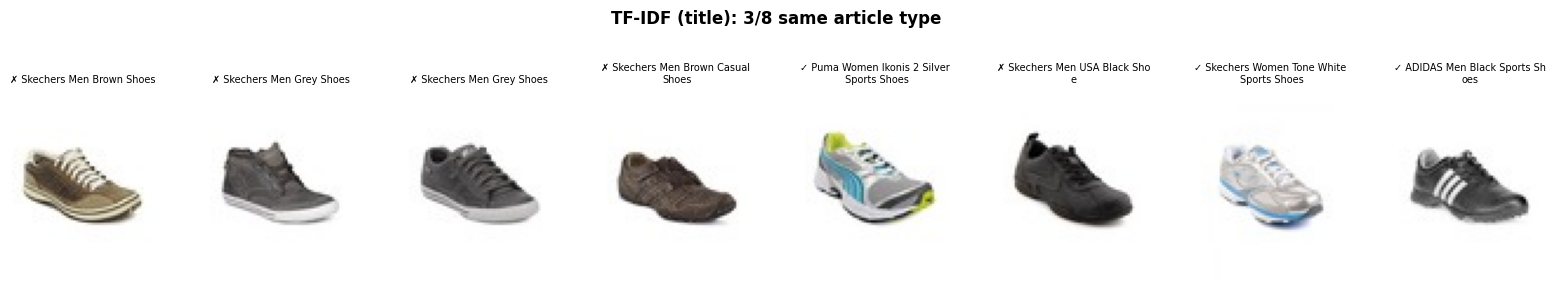

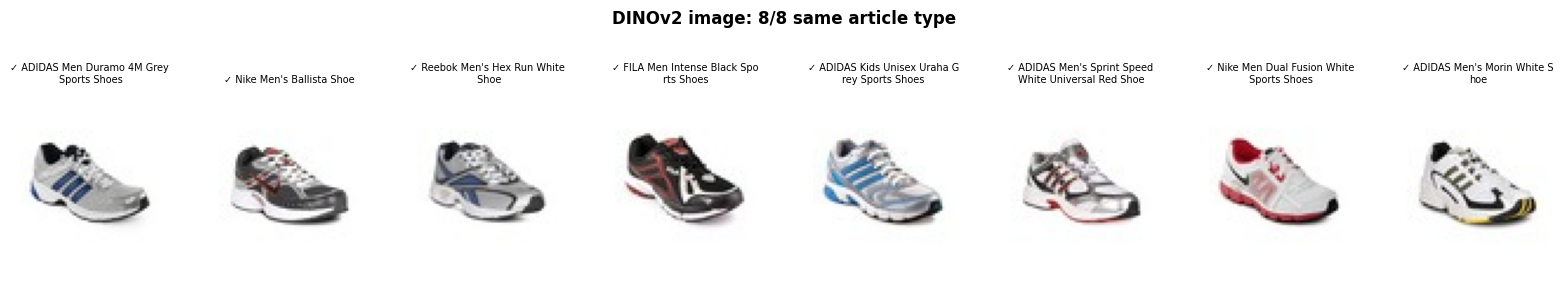

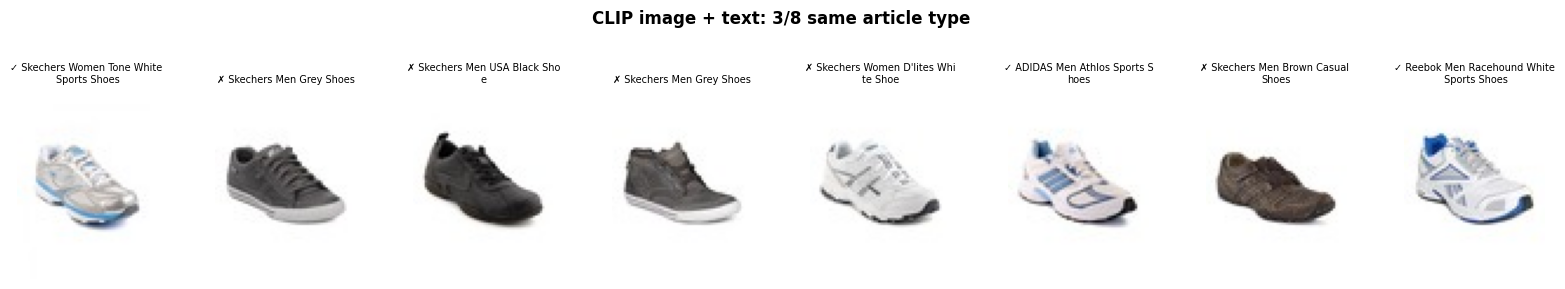

In [7]:
q = int(df.index[df["productDisplayName"].str.contains("Sports Shoes", na=False)][0])
print("Query:", df.iloc[q]["productDisplayName"], "|", df.iloc[q]["articleType"], "|", df.iloc[q]["baseColour"])
show_products([q], ncols=1, size=2.2)

for name in ["TF-IDF (title)", "DINOv2 image", "CLIP image + text"]:
    r = Recommender(SYSTEMS_BY_NAME[name], 0.5)
    S = r.item_scores()[q]
    idx, _ = r.top_k(S, 8, exclude=q)
    marks = ["✓ " if df.iloc[i]["articleType"] == df.iloc[q]["articleType"] else "✗ " for i in idx]
    hits = sum(m.startswith("✓") for m in marks)
    show_products(idx, [m + df.iloc[i]["productDisplayName"] for m, i in zip(marks, idx)],
                  header=f"{name}: {hits}/8 same article type")

## 5. Quantitative evaluation

**Task A: item-to-item ("more like this").** Every product is used as a query and we retrieve the top 10 other products.
- *i2i*: a result is relevant if it has the same `articleType`
- *i2i-strict*: a result is relevant if it has the same `articleType` **and** `baseColour`

**Task B: text search.** 261 shopper-style queries generated from metadata (e.g. *"white sports shoes for men"*). A result is relevant if colour, article type and gender all match.

Metrics: Precision@k, mAP@10 and NDCG@10. Task A is recomputed live below. Task B needs the text encoders loaded, so it is read from `results/` (produced by `python -m src.evaluate`).

In [8]:
art = df["articleType"].values
art_col = (df["articleType"] + "|" + df["baseColour"].astype(str)).values
live = []
for s in SYSTEMS:
    r = Recommender(s, 0.5)
    a, b = eval_item2item(r, art), eval_item2item(r, art_col)
    live.append({"system": s.name, "group": s.group, "i2i P@5": a["P@5"], "i2i NDCG@10": a["NDCG@10"],
                 "strict NDCG@10": b["NDCG@10"]})
live = pd.DataFrame(live)

saved = pd.read_csv(RESULTS_DIR / "model_comparison.csv")
table = live.merge(saved[["system", "search P@10", "search NDCG@10", "encode ms/item"]], on="system")
table.style.background_gradient(subset=["i2i NDCG@10", "strict NDCG@10", "search NDCG@10"], cmap="Greens") \
     .format(precision=3, na_rep="n/a")

,system,group,i2i P@5,i2i NDCG@10,strict NDCG@10,search P@10,search NDCG@10,encode ms/item
0,TF-IDF (title),text,0.689,0.658,0.352,0.224,0.402,0.070
1,MiniLM (title),text,0.758,0.733,0.309,0.355,0.607,8.620
2,CLIP text,text,0.777,0.758,0.518,0.341,0.570,25.070
3,SigLIP text,text,0.744,0.718,0.371,0.178,0.312,162.050
4,ResNet50 image,image,0.686,0.679,0.257,n/a,n/a,165.820
5,DINOv2 image,image,0.766,0.758,0.244,n/a,n/a,206.700
6,CLIP image,image,0.749,0.742,0.290,0.295,0.453,146.230
7,SigLIP image,image,0.817,0.807,0.291,0.392,0.618,528.120
8,DINOv2 + MiniLM (late fusion),multimodal,0.844,0.835,0.332,0.355,0.607,215.320
9,CLIP image + text,multimodal,0.828,0.815,0.527,0.379,0.625,171.300


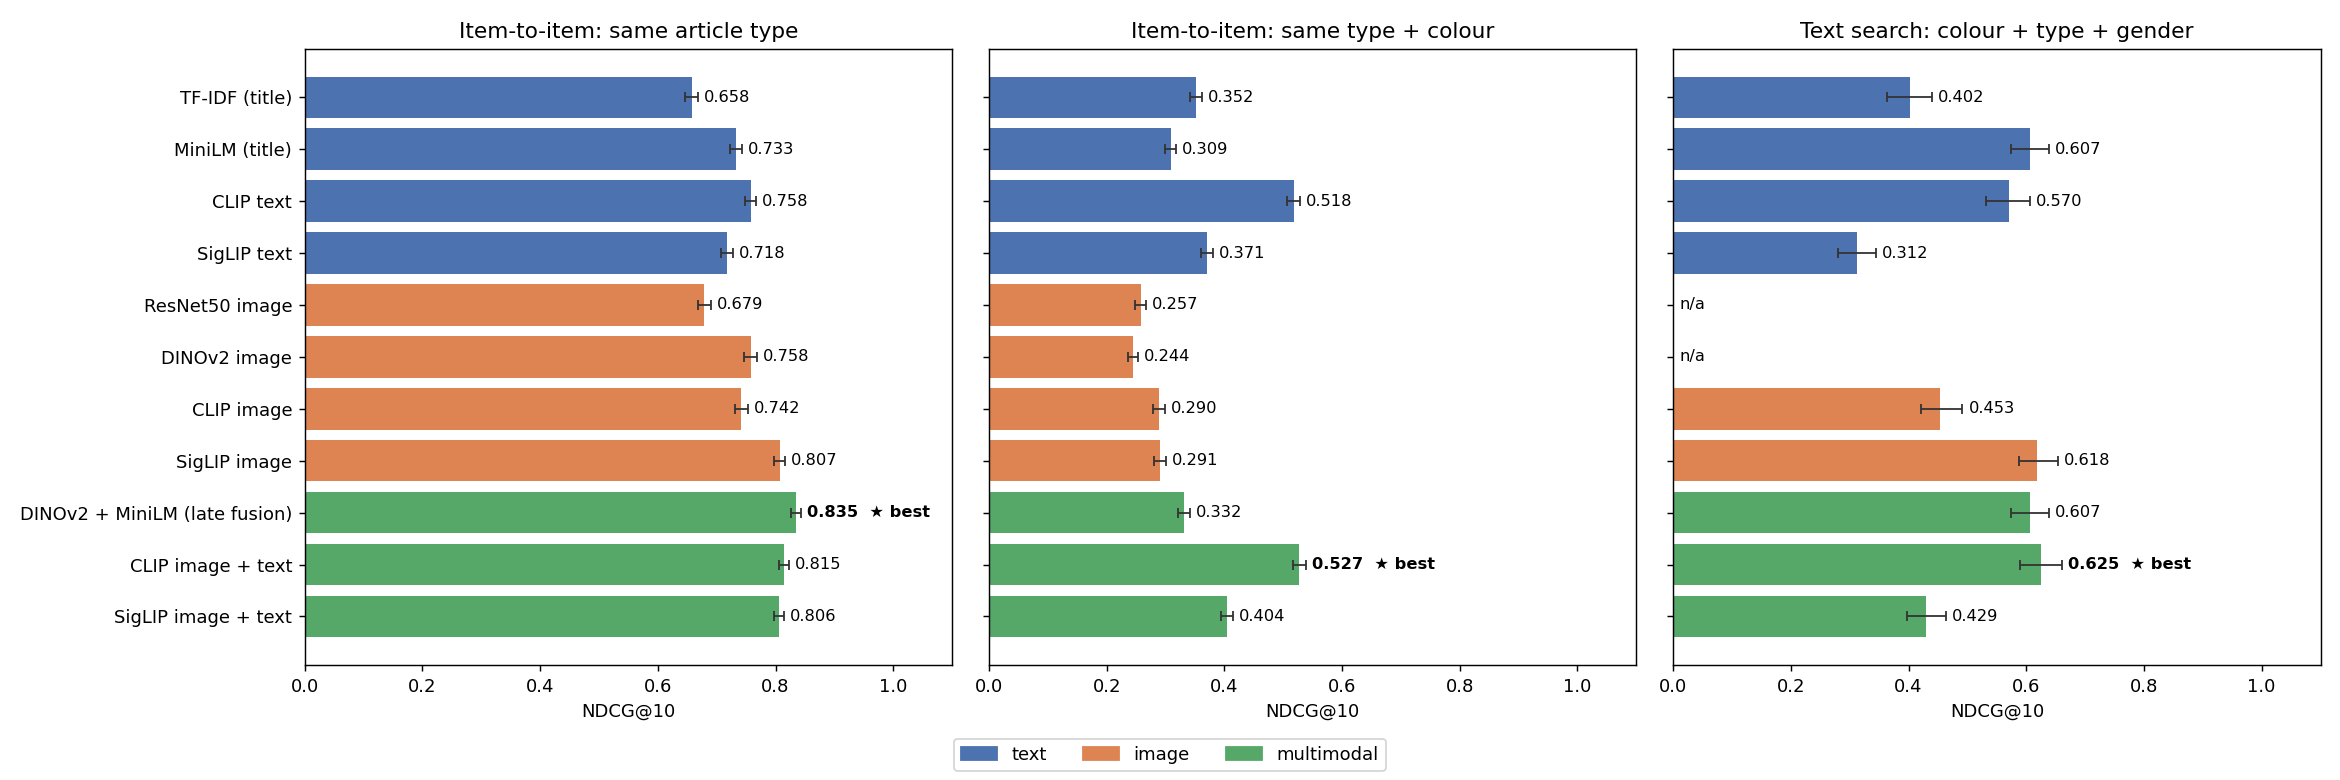

In [9]:
from IPython.display import Image as IPImage
IPImage(filename=str(RESULTS_DIR / "model_comparison.png"))

### Fusion-weight sweep

How does the image/text balance affect quality? $w=0$ is text only and $w=1$ is image only.

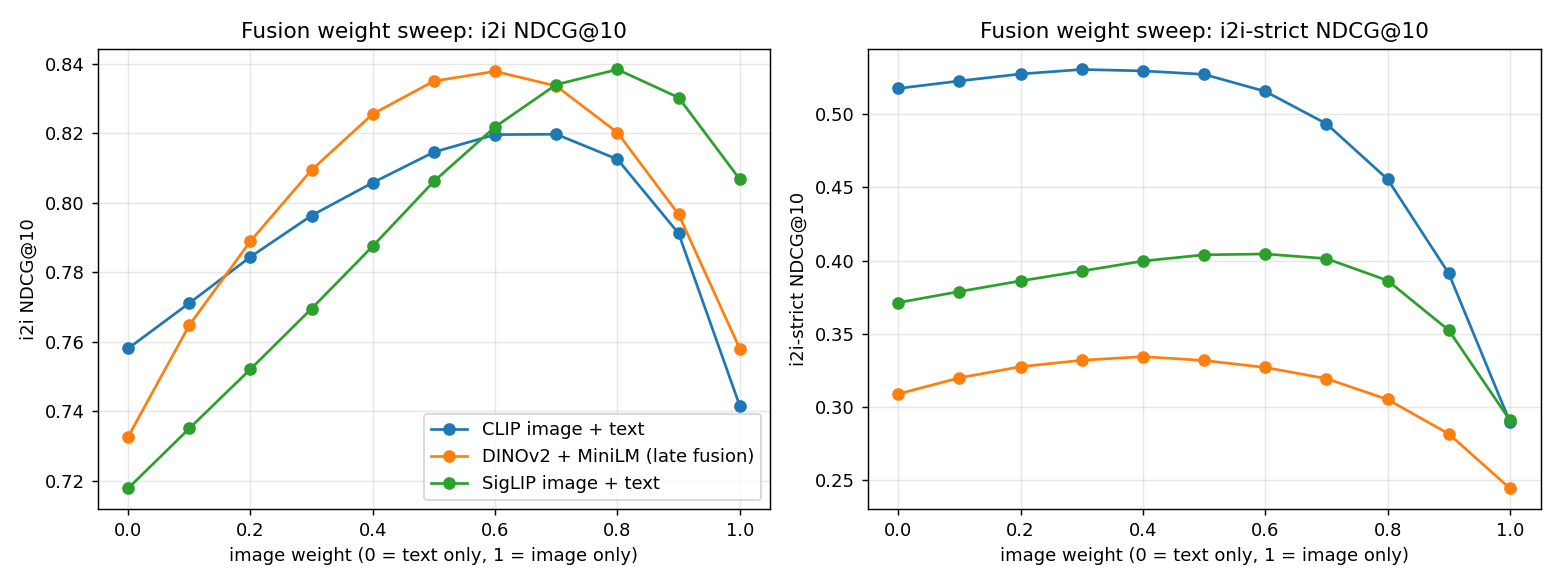

In [10]:
IPImage(filename=str(RESULTS_DIR / 'fusion_sweep.png'))

In [11]:
sweep = pd.read_csv(RESULTS_DIR / "fusion_sweep.csv")
sweep.loc[sweep.groupby("system")["i2i NDCG@10"].idxmax()].rename(columns={"image_weight": "best image weight"})

,system,best image weight,i2i NDCG@10,i2i-strict NDCG@10
18,CLIP image + text,0.7,0.820,0.493
6,DINOv2 + MiniLM (late fusion),0.6,0.838,0.327
30,SigLIP image + text,0.8,0.838,0.386


## 6. Embedding-space visualisation (t-SNE)

CLIP image embeddings compared with fused CLIP image + text embeddings, coloured by sub-category.

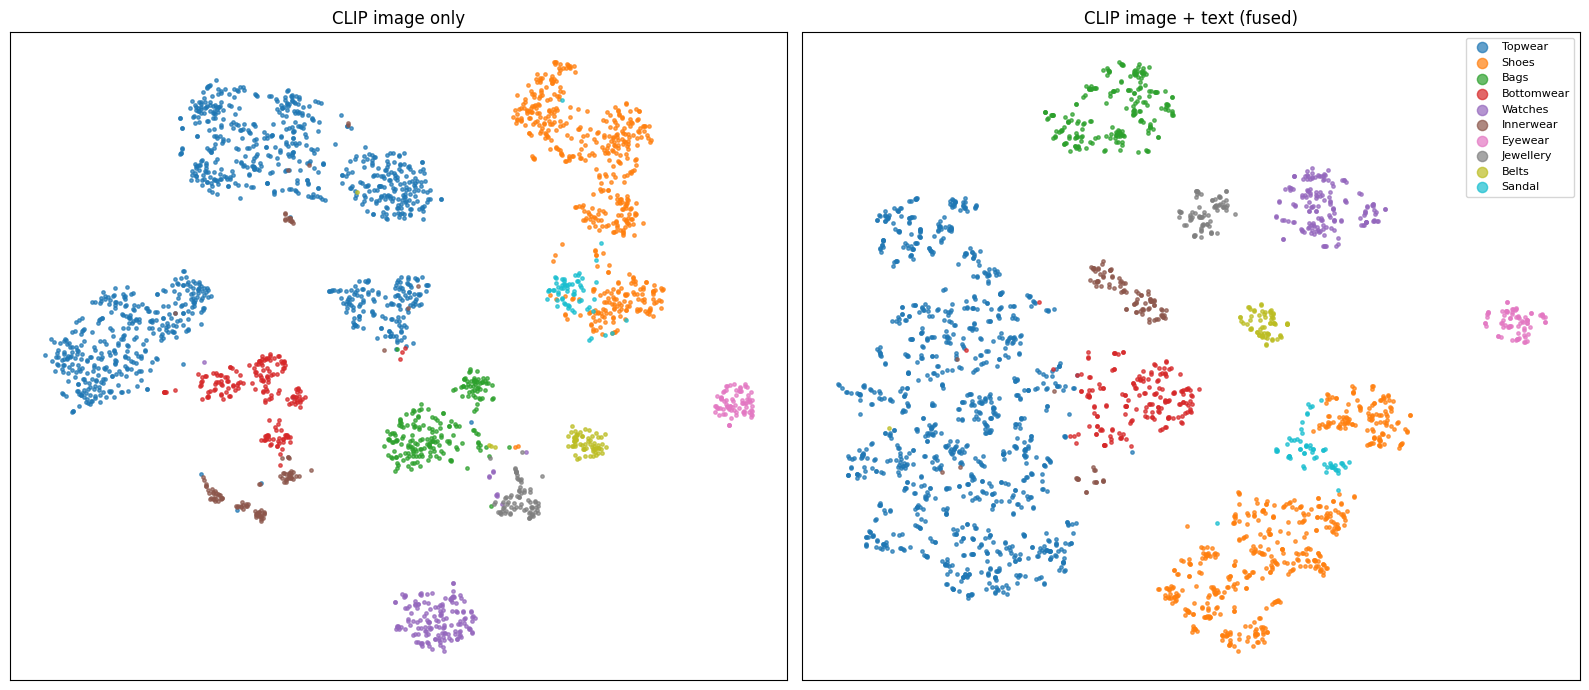

In [12]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

I, T = embeddings.load("CLIP", "image"), embeddings.load("CLIP", "text")
fused = np.hstack([np.sqrt(0.5) * I, np.sqrt(0.5) * T])
top = df["subCategory"].value_counts().head(10).index
mask = df["subCategory"].isin(top).values

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (title, X) in zip(axes, [("CLIP image only", I), ("CLIP image + text (fused)", fused)]):
    Z = TSNE(n_components=2, init="pca", random_state=0, perplexity=30).fit_transform(
        PCA(50, random_state=0).fit_transform(X[mask]))
    for c in top:
        m = df.loc[mask, "subCategory"].values == c
        ax.scatter(Z[m, 0], Z[m, 1], s=6, label=c, alpha=0.7)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
axes[1].legend(markerscale=3, fontsize=8, loc="best")
plt.tight_layout()

## 7. Zero-shot text-to-image search with CLIP

The text query is matched against product **images** only; titles are not used.

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

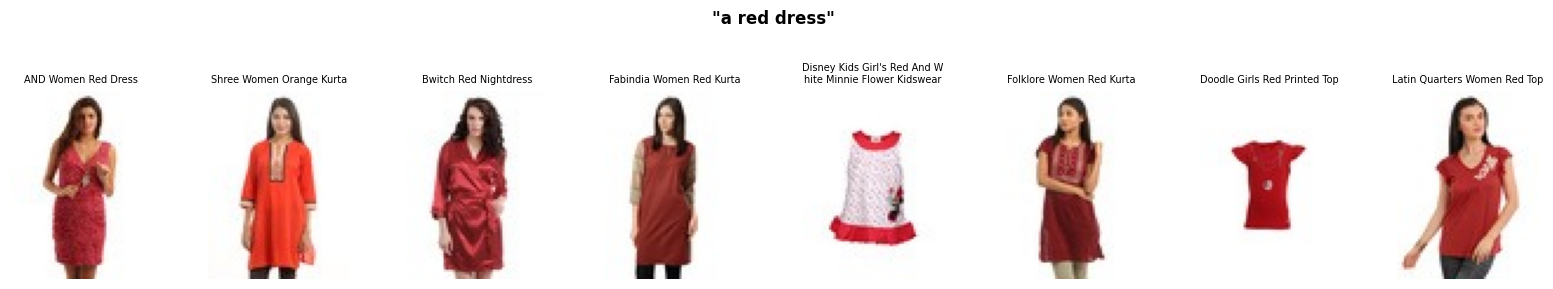

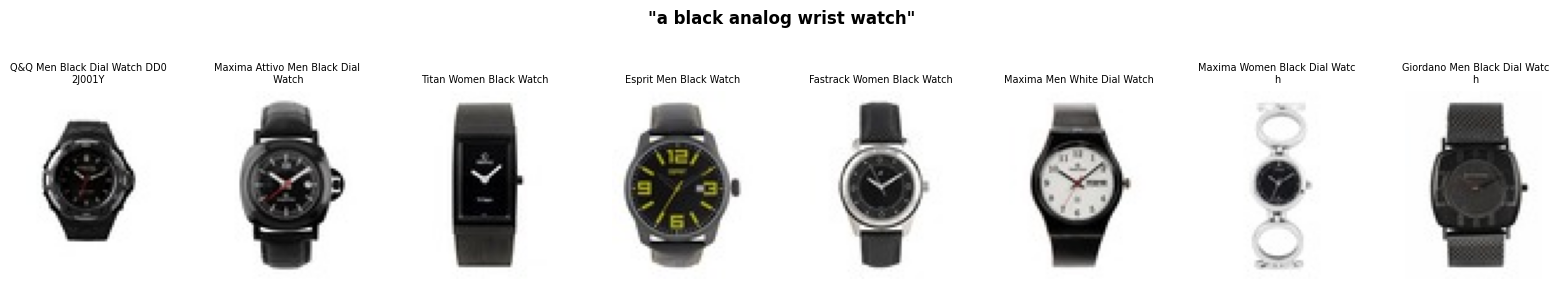

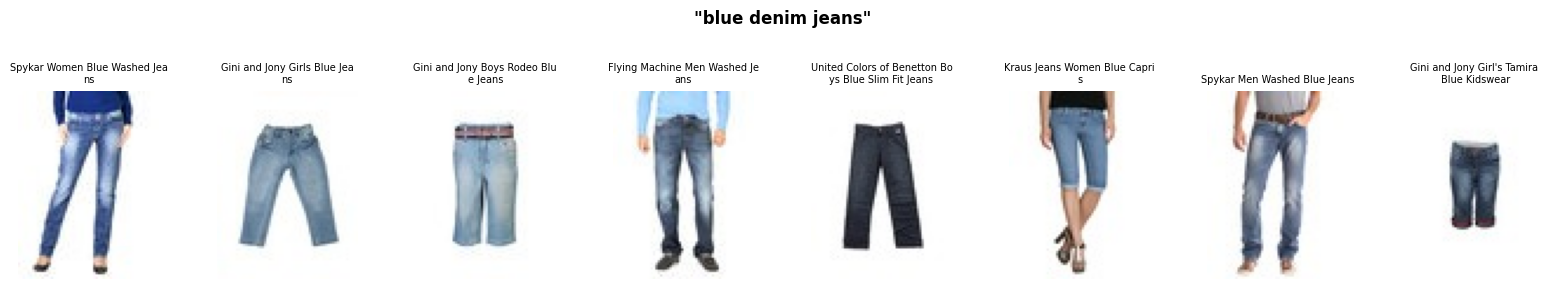

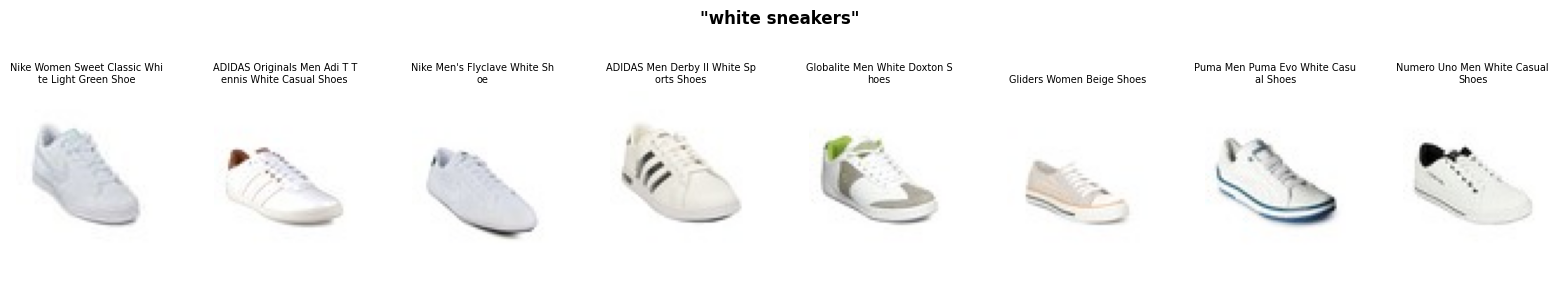

In [13]:
from src.encoders import CLIPEncoder
clip = CLIPEncoder()
img_only = Recommender(SYSTEMS_BY_NAME["CLIP image"])
for query in ["a red dress", "a black analog wrist watch", "blue denim jeans", "white sneakers"]:
    qv = clip.encode_text([query])[0]
    idx, _ = img_only.top_k(img_only.query_scores(q_txt_imgenc=qv), 8)
    show_products(idx, header=f'"{query}"')

## 8. Composed query: image + text modifier

In CLIP's shared space we can add a text vector to an image vector: *this product, but ...*

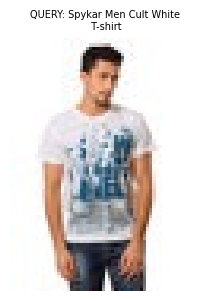

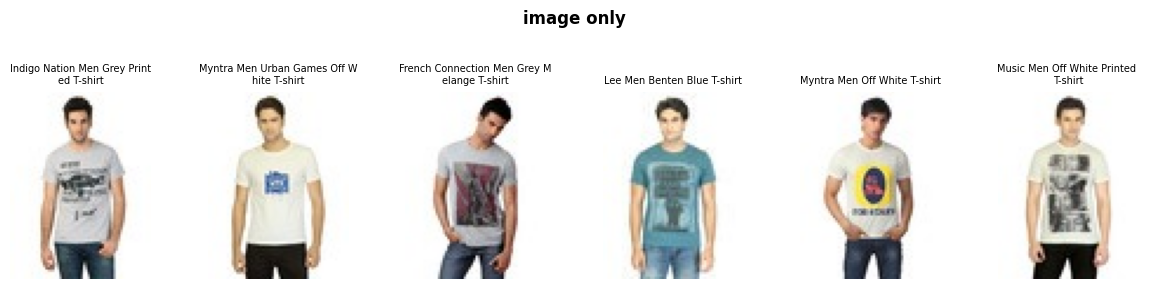

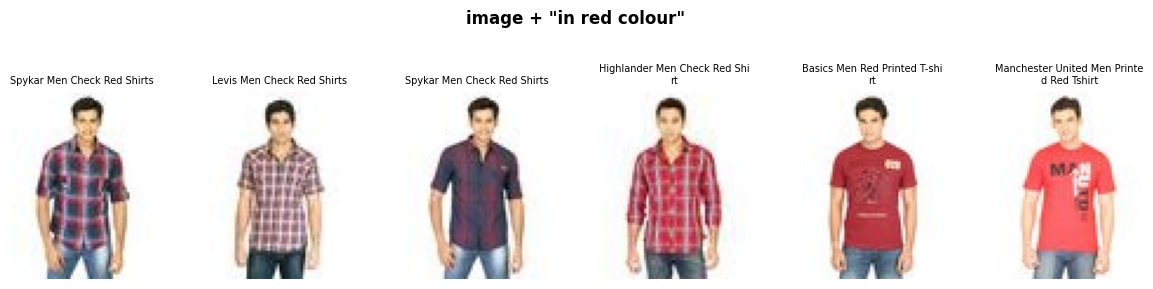

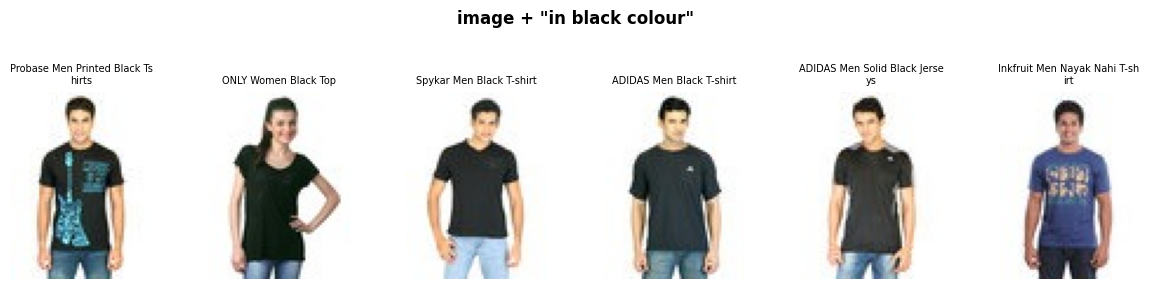

In [14]:
r = Recommender(SYSTEMS_BY_NAME["CLIP image + text"], 0.5)
q = int(df.index[(df["articleType"] == "Tshirts") & (df["baseColour"] == "White")][0])
vi = clip.encode_image([str(IMAGE_DIR / df.iloc[q]["image_path"])])[0]
show_products([q], ["QUERY: " + df.iloc[q]["productDisplayName"]], ncols=1, size=2.2)
for mod in [None, "in red colour", "in black colour"]:
    kw = dict(q_img=vi, q_img_textenc=vi)
    if mod:
        vt = clip.encode_text([mod])[0]
        kw |= dict(q_txt=vt, q_txt_imgenc=vt)
    idx, _ = r.top_k(r.query_scores(**kw), 6, exclude=q)
    show_products(idx, ncols=6, header="image only" if mod is None else f'image + "{mod}"')

## 9. Conclusions

1. **Multimodal fusion beats either modality alone.** Each fused system scores above its own image-only and text-only parts on item-to-item recommendation (best: DINOv2 + MiniLM at 0.835 NDCG@10).
2. **CLIP image + text is the best overall trade-off.** It is best on the colour-sensitive strict task (0.527) and on text search (0.625), at about 171 ms/item on CPU.
3. **Image embeddings capture shape and style but not colour.** Strict NDCG for image-only models is about 0.25–0.29; the colour signal comes mostly from the text.
4. **The best image weight is about 0.3–0.6.** Using only one modality at either extreme loses accuracy.
5. **A shared embedding space adds features:** zero-shot text-to-image search and composed "image + modifier" queries.

**Limitations and future work:** brand names in titles bias text similarity toward the same brand. Relevance is judged by metadata proxies rather than real user interactions. The catalog is a 3k sample. Next steps: fine-tune CLIP on the catalog, strip brand names from titles, use approximate nearest-neighbour indexing (FAISS) for larger catalogs, and learn fusion weights from click data.